# Lab 1: EPSS

## Preparing the enviroment

In [1]:

import pandas as pd
import os
import requests
import json
import seaborn as sns
import matplotlib.pyplot as plt
from fontTools.misc.cython import returns

from preprocessing_utils import preprocess_NVD_data

# Data Folder
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

## Data gathering
### EPSS data

I downloaded and unzipped the csv file containing the EPSS scores.

In [2]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)

### NVD data

This is the code to download the json file from NVD, merge it with the EPSS file and then save it as a csv.

In [3]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z'  # Do NOT change these dates
date_end_NVD = '2025-10-01T00:00:00.000Z'  # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)

# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus'] != 'Reserved') & (df['cve.vulnStatus'] != 'Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)

# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

1000
2000
3000
4000
5000


## Exploratory Data Analysis

Let's have an initial look at the data.

1. Starting from exploring the first 4 CVE records:

In [4]:
df.head(4).T

,0,1,2,3
cve.id,CVE-2025-9751,CVE-2025-9752,CVE-2025-9753,CVE-2025-9754
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000,2025-09-01 01:15:47.060000,2025-09-01 02:15:45.223000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000,2025-09-04 18:46:50.757000,2025-09-04 18:46:58.453000
cve.vulnStatus,Analyzed,Analyzed,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...,[{'url': 'https://github.com/Yashh-G/zero-day-...,[{'url': 'https://github.com/Yashh-G/zero-day-...
cve.cisaExploitAdd,NaN,NaN,NaN,NaN
cve.cisaActionDue,NaN,NaN,NaN,NaN
cve.cisaRequiredAction,NaN,NaN,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN,NaN,NaN


2. Show a bar plot with the daily volume of published CVEs:

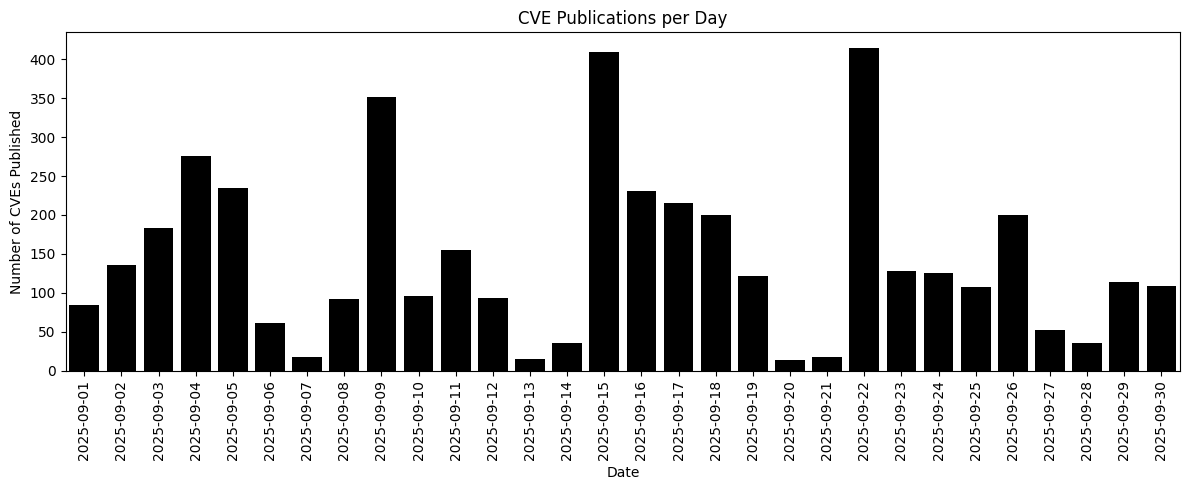

In [5]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k")
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

3. Print the description of the last ten published vulnerabilities:

In [6]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-' * 100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)

----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### TO-DOs
<font color='blue'>Use text cells to discuss the outcome after each point</font>
#### CVSS

1. Percentage of CVEs which received a CVSS score:

In [7]:
cvss_rows = df["cvss_baseScore"].notna().sum()
all_rows = len(df["cvss_baseScore"])
percentage = cvss_rows / all_rows * 100
print(f"CVEs with a CVSS score: {cvss_rows}/{all_rows}")
print(f"Percentage: {percentage:.2f}%")

CVEs with a CVSS score: 3777/4322
Percentage: 87.39%


Almost $\frac 14$ of the CVE doesn't have a CVSS value assigned.

2. Descriptive statistics of CVSS (I chose to consider only the vulnerabilities with a CVSS score assigned) and representation in a graph.

Statistics of CVSS scores:
count    3777.000000
mean        6.820069
std         1.760202
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64


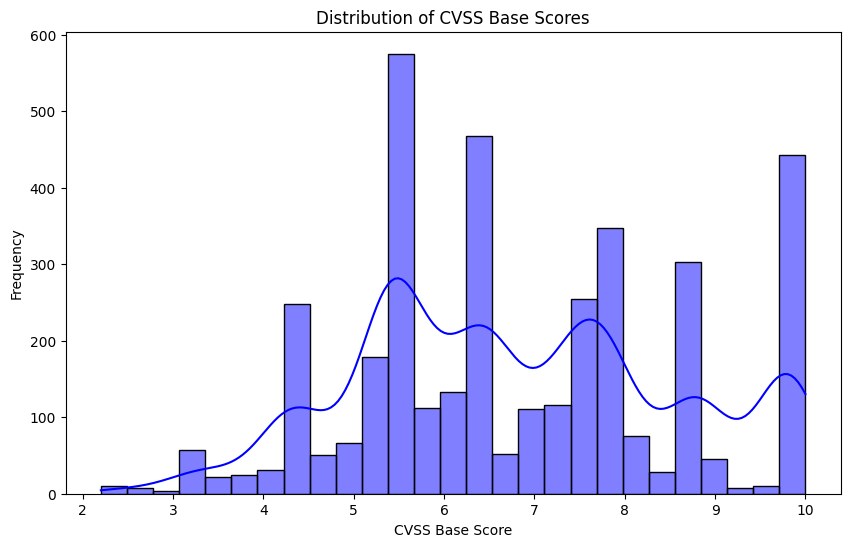

In [8]:
print("Statistics of CVSS scores:")
df_with_cvss = df.dropna(subset=["cvss_baseScore"])
print(df_with_cvss["cvss_baseScore"].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_with_cvss["cvss_baseScore"], kde=True, color="blue")
plt.title("Distribution of CVSS Base Scores")
plt.xlabel("CVSS Base Score")
plt.ylabel("Frequency")
plt.show()

3. Distribution of categorical values of the CVSS severities:

cvss_baseSeverity
MEDIUM      1913
HIGH        1239
CRITICAL     502
LOW          123
Name: count, dtype: int64


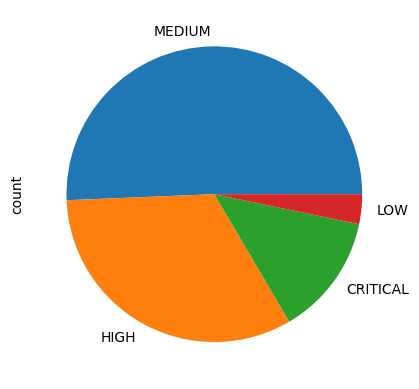

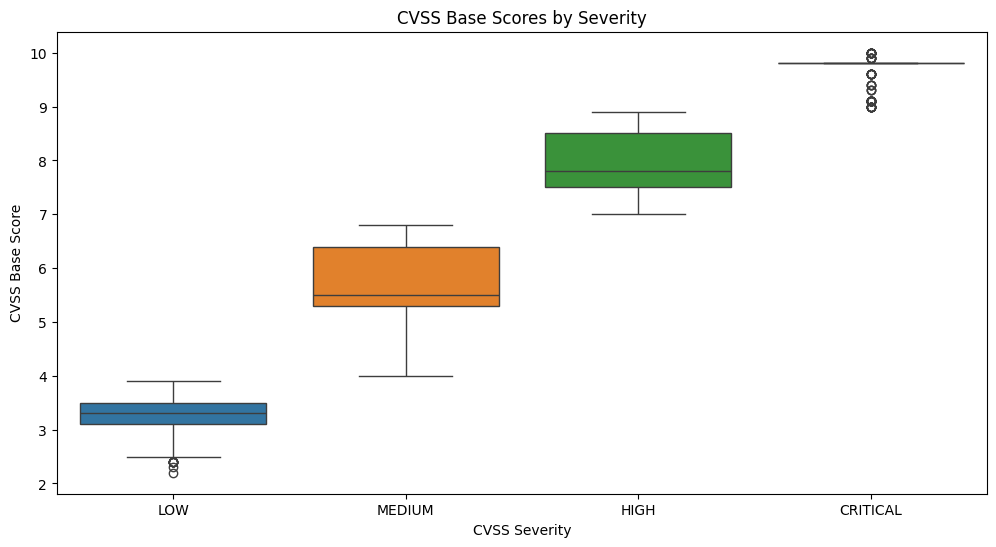

In [9]:
print(df_with_cvss["cvss_baseSeverity"].value_counts())

# Pie plot
df_with_cvss["cvss_baseSeverity"].value_counts().plot(kind="pie")

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x="cvss_baseSeverity", y="cvss_baseScore", data=df_with_cvss, hue="cvss_baseSeverity", legend=False)
plt.title("CVSS Base Scores by Severity")
plt.xlabel("CVSS Severity")
plt.ylabel("CVSS Base Score")
plt.show()


The majority of vulnerabilities have a medium risk. The critical vulnerabilities are the ones with the most consistent values of CVSS.

### EPSS

4. Report descriptive statistics of EPSS and/or show its distribution

In [10]:
print("Statistics of EPSS scores:")
print(df["epss"].describe())
print(df["epss"])

plt.figure(figsize=(12, 6))
plt.xlim(0, 0.002)
sns.histplot(df["epss"], color="red")
plt.title("Distribution of EPSS Scores")
plt.xlabel("EPSS Score")
plt.ylabel("Frequency")
plt.show()

Statistics of EPSS scores:
count    4322.000000
mean        0.001477
std         0.017285
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64
0       0.00030
1       0.00242
2       0.00026
3       0.00028
4       0.00028
         ...   
4317    0.00018
4318    0.00027
4319    0.00150
4320    0.00028
4321    0.00017
Name: epss, Length: 4322, dtype: float64


KeyboardInterrupt: 

We can see that the values of the EPSS are condensed in the very low values. This makes sense since all these vulnerabilities are quite new and therefore the probability of them being exploited are low.

EPSS Statistics:
count    4326.000000
mean        0.001476
std         0.017277
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64
0       0.00030
1       0.00242
2       0.00026
3       0.00028
4       0.00028
         ...   
4321    0.00018
4322    0.00027
4323    0.00150
4324    0.00028
4325    0.00017
Name: epss, Length: 4326, dtype: float64


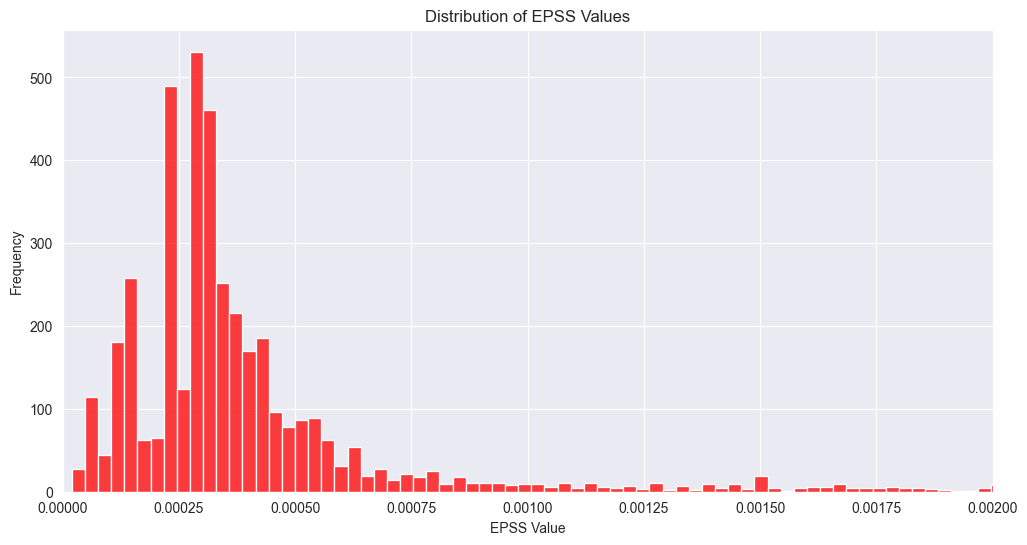

In [ ]:
# report descriptive statistics of EPSS and/or show its distribution

print("EPSS Statistics:")
print(df['epss'].describe())

print(df["epss"])

plt.figure(figsize=(12, 6))
plt.xlim(0, 0.002)
sns.histplot(df["epss"], color="red")
plt.xlabel("EPSS Value")
plt.ylabel("Frequency")
plt.title("Distribution of EPSS Values")
plt.show()



5. Produce a scatter plot showing CVSS vs EPSS

Correlazione CVSS–EPSS: 0.06


<Axes: xlabel='cvss_baseScore', ylabel='epss'>

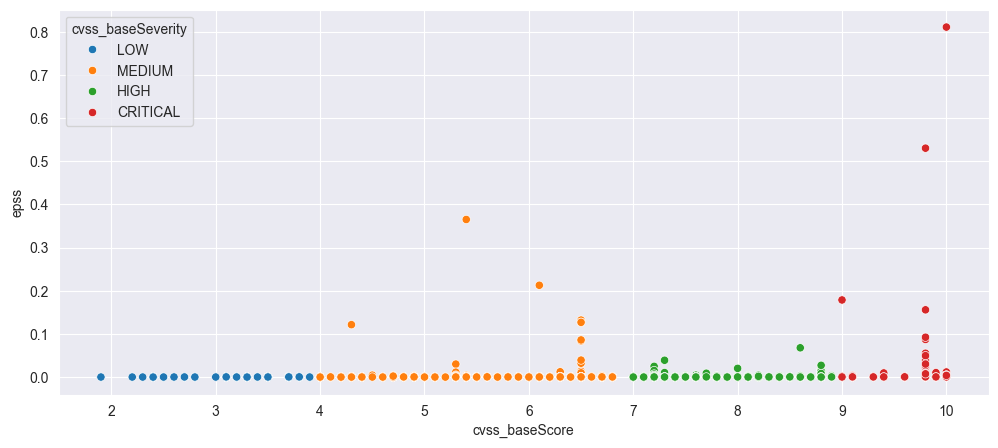

In [ ]:
plt.figure(figsize=(12, 5))
corr = df['cvss_baseScore'].corr(df['epss'])
print(f"Correlazione CVSS–EPSS: {corr:.2f}")

# Scatterplot
sns.scatterplot(data=df, x="cvss_baseScore", y="epss", hue='cvss_baseSeverity')

We can see that the values are not very correlated. But this makes sense, since EPSS values are very low for almost all of them.

### CISA

6. Visualize the CVE with a CISA required action.


In [ ]:
df_exploited = df.dropna(subset=["cve.cisaRequiredAction"])
df_exploited["cve.cisaRequiredAction"].describe()

count                                                     9
unique                                                    2
top       Apply mitigations per vendor instructions, fol...
freq                                                      7
Name: cve.cisaRequiredAction, dtype: object

There are only 9 entries that have a non null CISA required action, that can be generally considered a high priority. In fact, the presence of this field indicates verified exploitation and officially mandated action. Therefore, I thought it would be interesting to visualize them.

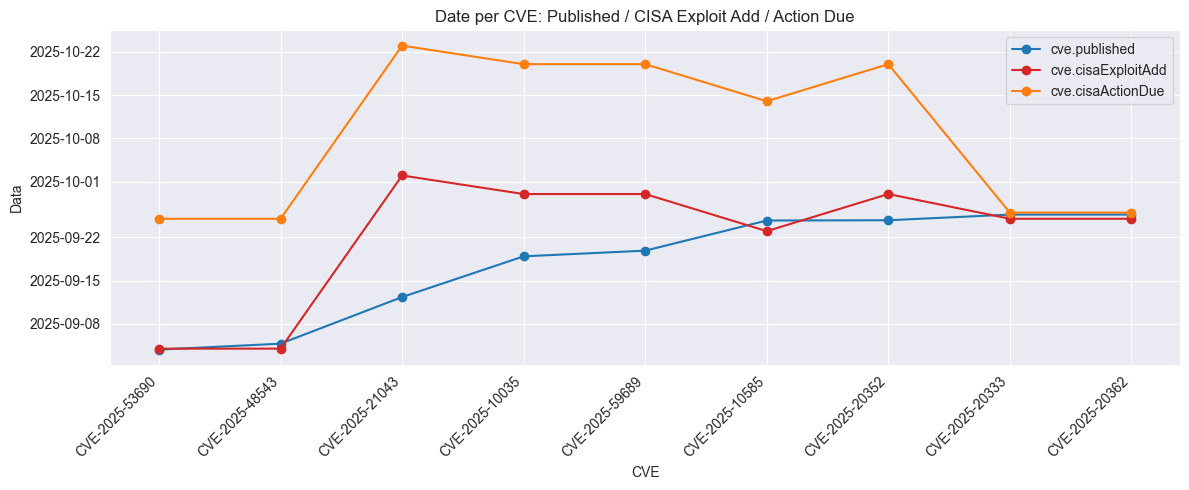

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

cols = ["cve.published", "cve.cisaExploitAdd", "cve.cisaActionDue"]

# Conversione in datetime per sicurezza
df_exploited = df_exploited.copy()
df_exploited[cols] = df_exploited[cols].apply(pd.to_datetime, errors="coerce")

# Usa l'indice per le CVE (es. cve.id)
x_labels = df_exploited["cve.id"]
x_positions = range(len(df_exploited))

plt.figure(figsize=(12, 5))

for col, color in zip(cols, ["tab:blue", "tab:red", "tab:orange"]):
    plt.plot(x_positions, df_exploited[col], marker='o', label=col, color=color)

plt.xticks(x_positions, x_labels, rotation=45, ha='right')
plt.xlabel("CVE")
plt.ylabel("Data")
plt.title("Date per CVE: Published / CISA Exploit Add / Action Due")
plt.legend()
plt.tight_layout()
plt.show()



We can see that all these vulnerabilities have been already exploited, and some of them are even zero-days vulnerabilities.

<Axes: xlabel='cvss_baseScore', ylabel='epss'>

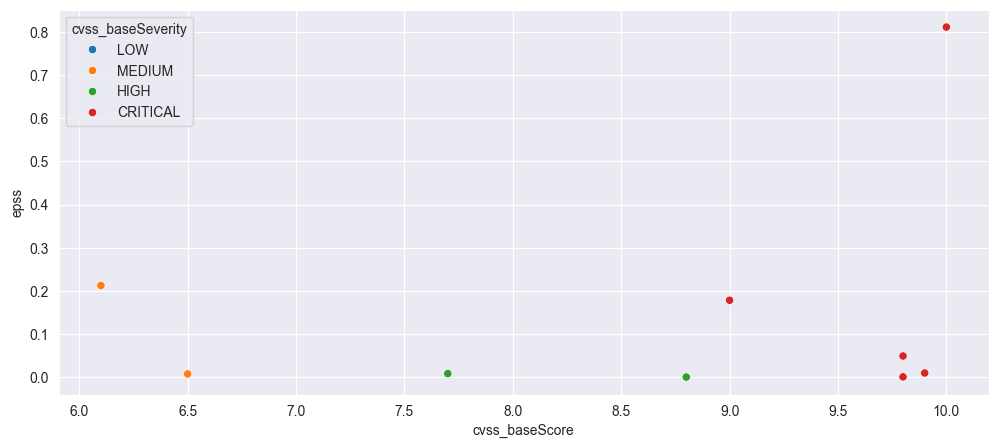

In [ ]:
plt.figure(figsize=(12, 5))
# Scatterplot
sns.scatterplot(data=df_exploited, x="cvss_baseScore", y="epss", hue='cvss_baseSeverity')

More than half of these selected vulnerabilities have a CRITICAL base severity value.

### Misc

7. See distribution of attack complexity, attack vector, privileges required, user interaction, scope.

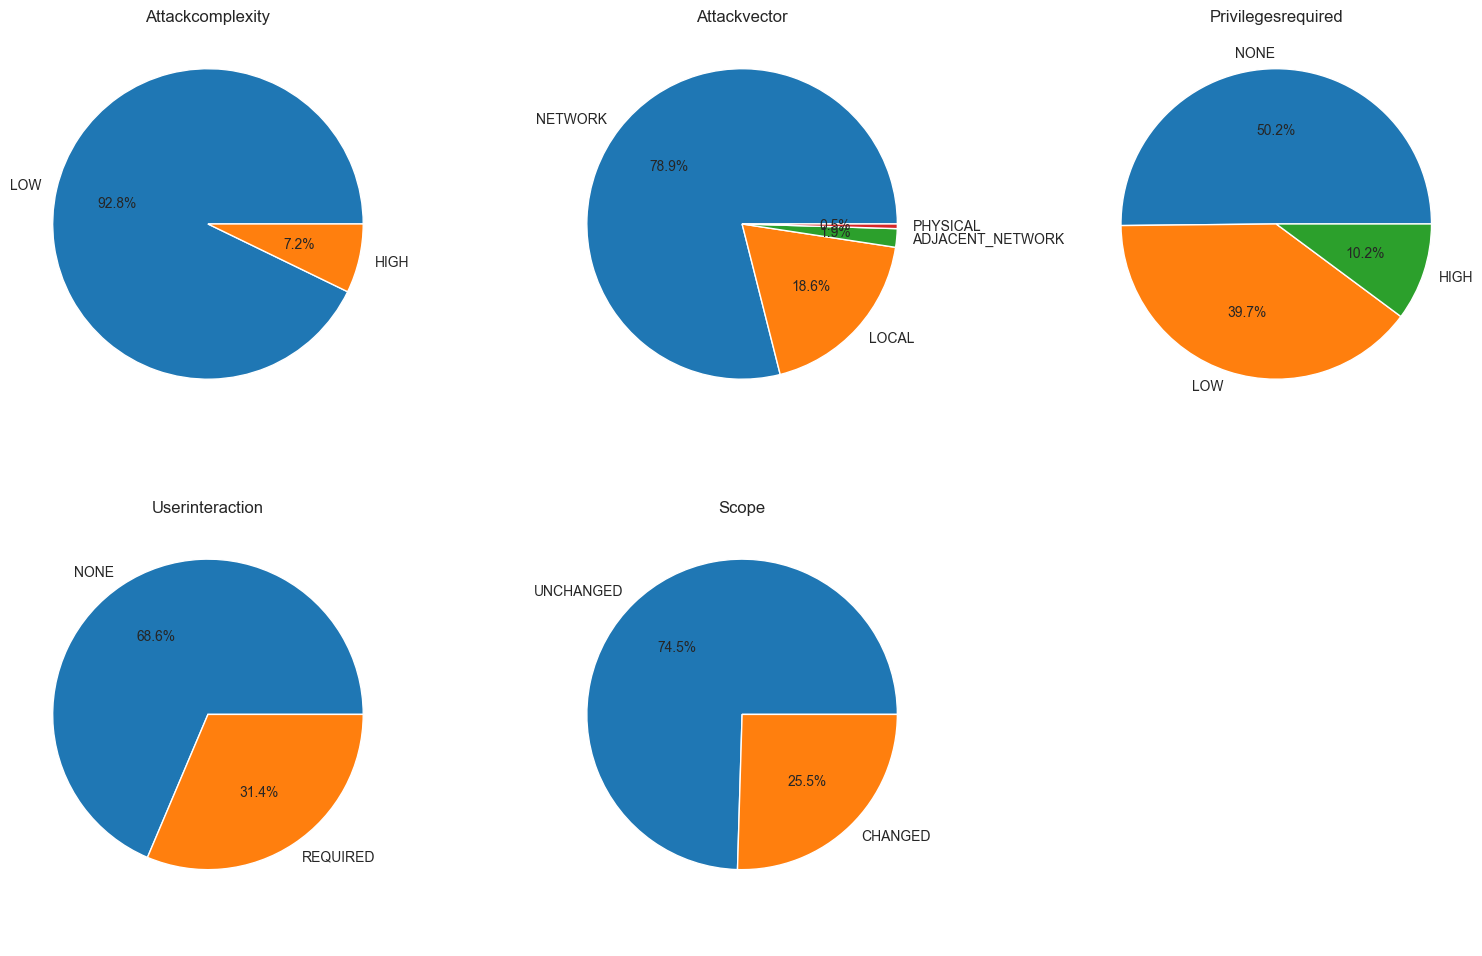

In [ ]:
import matplotlib.pyplot as plt

# Lista delle colonne da visualizzare
colonne = ["cvss_attackComplexity", "cvss_attackVector",
           "cvss_privilegesRequired", "cvss_userInteraction", "cvss_scope"]

# Crea una griglia di 2 righe x 3 colonne
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Appiattisci la griglia (così è più facile iterare)
axes = axes.flatten()

# Per ogni colonna, crea un grafico a torta
for i, col in enumerate(colonne):
    df[col].value_counts().plot(kind="pie", ax=axes[i], autopct='%1.1f%%')
    axes[i].set_title(col.replace("cvss_", "").replace("_", " ").title())
    axes[i].set_ylabel("")  # Toglie l'etichetta "None" sull'asse Y

axes[5].axis('off')

plt.tight_layout()
plt.show()

8. Analyze the possible impacts.


In [ ]:
import plotly.express as px

df_agg = df.groupby(["cvss_confidentialityImpact",
                     "cvss_integrityImpact",
                     "cvss_availabilityImpact",
                     "cvss_baseSeverity"], observed=True).size().reset_index(name="count")

fig = px.scatter_3d(df_agg,
                    x="cvss_confidentialityImpact",
                    y="cvss_integrityImpact",
                    z="cvss_availabilityImpact", # Dimensione = quante CVE
                    color="cvss_baseSeverity",
                    size="count",
                    hover_data=["count"],
                    size_max=200,
                    height=600)

fig.update_layout(scene=dict(
    xaxis_title="Confidentiality Impact",
    yaxis_title="Integrity Impact",
    zaxis_title="Availability Impact",
))
fig.show()

From this graph, we can see that the majority of vulnerabilities have a high impact on all three (CIA) and those have a critical or high severity.

10. See most common CWE.

In [ ]:
all_cwe = df["cwe_list"].explode()
print(all_cwe.value_counts().head(10))

cwe_list
CWE-79     711
CWE-89     428
CWE-74     294
CWE-862    203
CWE-352    160
CWE-94     134
CWE-284    119
CWE-77      97
CWE-78      89
CWE-434     86
Name: count, dtype: int64


The top 2 CWEs are:
* CWE-79: **Improper Neutralization of Input During Web Page Generation ('Cross-site Scripting')**:

  The product does not neutralize or incorrectly neutralizes user-controllable input before it is placed in output that is used as a web page that is served to other users.
* CWE-89: **Improper Neutralization of Special Elements used in an SQL Command ('SQL Injection')**:

    The product constructs all or part of an SQL command using externally-influenced input from an upstream component, but it does not neutralize or incorrectly neutralizes special elements that could modify the intended SQL command when it is sent to a downstream component. Without sufficient removal or quoting of SQL syntax in user-controllable inputs, the generated SQL query can cause those inputs to be interpreted as SQL instead of ordinary user data.

Source: https://cwe.mitre.org/data/definitions/79.html https://cwe.mitre.org/data/definitions/89.html

11. See most common vendors (vulnerable cpes)

In [ ]:
all_cpes = df["vulnerable_cpes"].explode()
print(all_cpes.value_counts().head(10))

vulnerable_cpes
cpe:2.3:o:google:android:14.0:*:*:*:*:*:*:*                     110
cpe:2.3:o:apple:macos:*:*:*:*:*:*:*:*                           109
cpe:2.3:o:google:android:15.0:*:*:*:*:*:*:*                     108
cpe:2.3:o:google:android:13.0:*:*:*:*:*:*:*                      99
cpe:2.3:o:microsoft:windows_server_2025:*:*:*:*:*:*:*:*          59
cpe:2.3:o:microsoft:windows_server_2022_23h2:*:*:*:*:*:*:*:*     57
cpe:2.3:o:microsoft:windows_server_2022:*:*:*:*:*:*:*:*          55
cpe:2.3:o:google:android:16.0:*:*:*:*:*:*:*                      54
cpe:2.3:o:microsoft:windows_server_2019:*:*:*:*:*:*:*:*          50
cpe:2.3:o:microsoft:windows_11_24h2:*:*:*:*:*:*:*:*              49
Name: count, dtype: int64


The results show that the most vulnerable vendors in this data are: android, macos and windows server.

### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time

In [11]:
df_low_cves = df[df["epss"] < 0.01]
df_low_cves.shape

(4264, 29)

In [12]:
df_selected_exploited = df_low_cves.dropna(subset=["cve.cisaRequiredAction"])
df_selected_exploited.head()

,cve.id,cve.sourceIdentifier,cve.published,cve.lastModified,cve.vulnStatus,cve.references,cve.cisaExploitAdd,cve.cisaActionDue,cve.cisaRequiredAction,cve.cisaVulnerabilityName,...,cvss_attackComplexity,cvss_privilegesRequired,cvss_userInteraction,cvss_scope,cvss_confidentialityImpact,cvss_integrityImpact,cvss_availabilityImpact,cve,epss,percentile
641,CVE-2025-48543,security@android.com,2025-09-04 19:15:40.780,2025-10-23 14:52:51.863,Analyzed,[{'url': 'https://android.googlesource.com/pla...,2025-09-04,2025-09-25,"Apply mitigations per vendor instructions, fol...",Android Runtime Use-After-Free Vulnerability,...,LOW,LOW,NONE,CHANGED,HIGH,HIGH,HIGH,CVE-2025-48543,0.00085,0.25870
1163,CVE-2025-54236,psirt@adobe.com,2025-09-09 14:15:46.563,2025-12-10 02:00:02.557,Analyzed,[{'url': 'https://helpx.adobe.com/security/pro...,2025-10-24,2025-11-14,"Apply mitigations per vendor instructions, fol...",Adobe Commerce and?Magento Improper Input Vali...,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,NONE,CVE-2025-54236,0.00333,0.55705
1717,CVE-2025-21042,mobile.security@samsung.com,2025-09-12 08:15:44.743,2025-11-12 14:32:28.317,Analyzed,[{'url': 'https://security.samsungmobile.com/s...,2025-11-10,2025-12-01,"Apply mitigations per vendor instructions, fol...",Samsung Mobile Devices Out-of-Bounds Write Vul...,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,CVE-2025-21042,0.00198,0.42262
1718,CVE-2025-21043,mobile.security@samsung.com,2025-09-12 08:15:44.920,2025-10-30 15:36:12.360,Analyzed,[{'url': 'https://security.samsungmobile.com/s...,2025-10-02,2025-10-23,"Apply mitigations per vendor instructions, fol...",Samsung Mobile Devices Out-of-Bounds Write Vul...,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,CVE-2025-21043,0.00137,0.34472
2498,CVE-2025-9242,5d1c2695-1a31-4499-88ae-e847036fd7e3,2025-09-17 08:15:33.960,2025-11-14 02:00:02.350,Analyzed,[{'url': 'https://www.watchguard.com/wgrd-psir...,2025-11-12,2025-12-03,"Apply mitigations per vendor instructions, fol...",WatchGuard Firebox Out-of-Bounds Write Vulnera...,...,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,CVE-2025-9242,0.00274,0.50799


In [13]:
df_selected_cves = df_low_cves[(df_low_cves['cvss_attackComplexity'] == "LOW") &
                               (df_low_cves['cvss_privilegesRequired'] == "NONE") &
                               (df_low_cves["cvss_userInteraction"] == "NONE") &
                               (df_low_cves["cvss_confidentialityImpact"] == "HIGH") &
                               (df_low_cves["cvss_integrityImpact"] == "HIGH") &
                               (df_low_cves["cvss_availabilityImpact"] == "HIGH") &
                               (df_low_cves["cvss_baseSeverity"] == "CRITICAL") &
                               (df_low_cves["cve.cisaRequiredAction"].isnull())]

# 5 most dangerous CWEs in 2024
dangerous_cwes_id = [79, 787, 89, 352, 22]
dangerous_cwes = []
for n in dangerous_cwes_id:
    dangerous_cwes.append("CWE-" + str(n))

def check(row):
    for a in row['cwe_list']:
        for b in dangerous_cwes:
            if a == b:
                return True
    return False

# selecting the cves with cwes in the most dangerous ones
df_selected_cves = df_selected_cves[df_selected_cves.apply(check, axis=1)]

# selecting non empty vulnerable cpes
df_selected_cves = df_selected_cves[df_selected_cves.apply(lambda row: row["vulnerable_cpes"] != [], axis=1)]

cols = [
    "cve.id",
    "description",
    "cwe_list",
    "epss",
    "cve.cisaRequiredAction"
]
df_selected_cves[cols].sort_values("epss", ascending=False).head(10)


,cve.id,description,cwe_list,epss,cve.cisaRequiredAction
2633,CVE-2025-59352,Dragonfly is an open source P2P-based file dis...,"[CWE-22, CWE-202]",0.00563,NaN
1589,CVE-2025-58321,Delta Electronics DIALink has an Directory Tra...,[CWE-22],0.00454,NaN
1427,CVE-2025-58447,rAthena is an open-source cross-platform massi...,"[CWE-122, CWE-787]",0.00256,NaN
2452,CVE-2025-57631,SQL Injection vulnerability in TDuckCloud v.5....,[CWE-89],0.00242,NaN
417,CVE-2025-36897,"In unknown of cd_CnMsgCodecUserApi.cpp, there ...",[CWE-787],0.00164,NaN
3086,CVE-2025-56074,A SQL Injection vulnerability was discovered i...,[CWE-89],0.00116,NaN
1406,CVE-2025-58462,OPEXUS FOIAXpress Public Access Link (PAL) bef...,[CWE-89],0.00099,NaN
71,CVE-2025-9791,A weakness has been identified in Tenda AC20 1...,"[CWE-119, CWE-121, CWE-787]",0.00084,NaN
72,CVE-2025-9809,Out-of-bounds write in cdfs_open_cue_track in ...,[CWE-787],0.00083,NaN
1389,CVE-2025-23343,The NVIDIA NVDebug tool contains a vulnerabili...,[CWE-22],0.00067,NaN


In [ ]:
nickname = 'CosaVerraExploitato' # TODO: put your nickname here


# TODO: put your selected IDs here
selected = ['CVE-2025-48543',
            'CVE-2025-21043',
            'CVE-2025-20352',
            'CVE-2025-20362',
            'CVE-2025-59352',
            'CVE-2025-58321',
            'CVE-2025-58447',
            'CVE-2025-57631',
            'CVE-2025-21042',
            'CVE-2025-36897',
           ]

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))